# Notebook 05 - Long Short-Term Memory (LSTM)

En este notebook implementamos una LSTM, que es una versión mejorada de la RNN diseñada para aprender dependencias a largo plazo en secuencias temporales.

## 1. Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

np.random.seed(42)
tf.random.set_seed(42)
print('Listo')

Listo


## 2. Carga de datos

In [2]:
DATA_DIR = '../data/processed'

X_tr = np.load(os.path.join(DATA_DIR, 'X_tr_seq.npy'))
X_val = np.load(os.path.join(DATA_DIR, 'X_val_seq.npy'))
X_test = np.load(os.path.join(DATA_DIR, 'X_test_seq.npy'))

y_tr = np.load(os.path.join(DATA_DIR, 'y_tr_seq.npy'))
y_val = np.load(os.path.join(DATA_DIR, 'y_val_seq.npy'))
y_test = np.load(os.path.join(DATA_DIR, 'y_test_seq.npy'))

y_test_int = np.load(os.path.join(DATA_DIR, 'y_test_int.npy'))

nombres_clases = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']

print('Train:', X_tr.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

Train: (5881, 128, 9)
Validation: (1471, 128, 9)
Test: (2947, 128, 9)


## 3. ¿Cómo funciona la LSTM?

La LSTM introduce un mecanismo de **compuertas (gates)** que controlan qué información se conserva y qué se descarta:

- **Compuerta de olvido (forget gate)**: decide qué información del estado anterior descartar.
- **Compuerta de entrada (input gate)**: decide qué nueva información agregar al estado.
- **Compuerta de salida (output gate)**: decide qué parte del estado pasar como salida.

Además, mantiene dos estados: el **estado de celda** (memoria a largo plazo) y el **estado oculto** (salida a corto plazo). Esto le permite aprender dependencias mucho más largas que la RNN simple.

## 4. Arquitectura de la LSTM

In [3]:
modelo_lstm = Sequential([
    # Primera capa LSTM
    LSTM(64, return_sequences=True, input_shape=(128, 9)),
    Dropout(0.2),

    # Segunda capa LSTM
    LSTM(32, return_sequences=False),
    Dropout(0.2),

    # Capa densa
    Dense(32, activation='relu'),

    # Salida
    Dense(6, activation='softmax')
])

modelo_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128, 64)        │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,614 (127.40 KB)

 Trainable params: 32,614 (127.40 KB)

 Non-trainable params: 0 (0.00 B)

Nótese que la LSTM tiene más parámetros que la RNN simple, ya que internamente implementa 4 conjuntos de pesos (uno por cada compuerta más la transformación de entrada). Esto la hace más expresiva pero también más lenta para entrenar.

## 5. Entrenamiento

In [4]:
modelo_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

inicio = time.time()

historial = modelo_lstm.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

tiempo_entrenamiento = time.time() - inicio
print(f'\nTiempo de entrenamiento: {tiempo_entrenamiento:.2f} segundos')

Epoch 1/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 338ms/step - accuracy: 0.5071 - loss: 1.2556 - val_accuracy: 0.5976 - val_loss: 0.9838
Epoch 2/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.6742 - loss: 0.7914 - val_accuracy: 0.7260 - val_loss: 0.6655
Epoch 3/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 169ms/step - accuracy: 0.7643 - loss: 0.6091 - val_accuracy: 0.8484 - val_loss: 0.4423
Epoch 4/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 181ms/step - accuracy: 0.8604 - loss: 0.4106 - val_accuracy: 0.8831 - val_loss: 0.3293
Epoch 5/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.9068 - loss: 0.2784 - val_accuracy: 0.9266 - val_loss: 0.2559
Epoch 6/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 170ms/step - accuracy: 0.9180 - loss: 0.2278 - val_accuracy: 0.8464 - val_loss: 0.4831
Epoch 7/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 151ms/step - accuracy: 0.9238 - loss: 0.2175 - val_accuracy: 0.9511 - val_loss: 0.1668
Epoch 8/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step - accuracy: 0.9318 - loss: 0.1830 - val_accu

## 6. Curvas de Aprendizaje

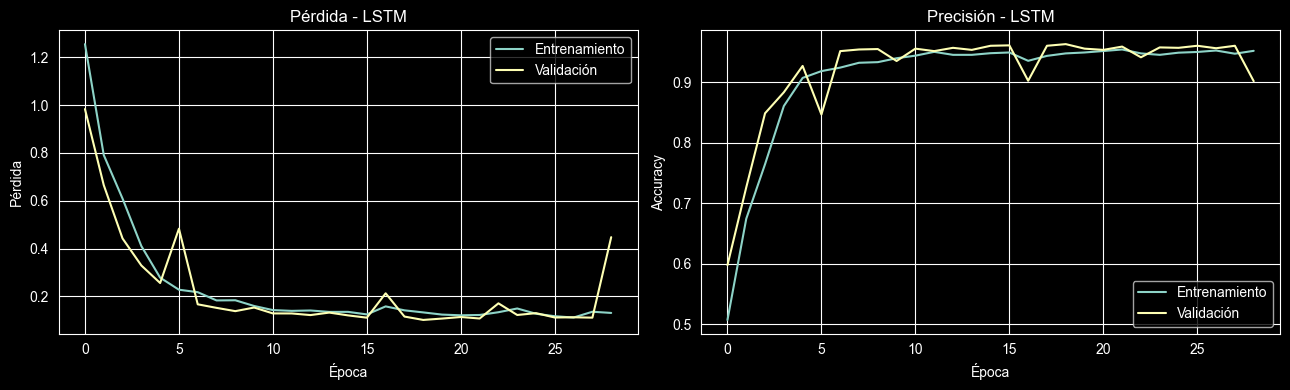

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(historial.history['loss'], label='Entrenamiento')
axes[0].plot(historial.history['val_loss'], label='Validación')
axes[0].set_title('Pérdida - LSTM')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].legend()

axes[1].plot(historial.history['accuracy'], label='Entrenamiento')
axes[1].plot(historial.history['val_accuracy'], label='Validación')
axes[1].set_title('Precisión - LSTM')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/curvas_lstm.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Evaluación

In [6]:
y_pred_prob = modelo_lstm.predict(X_test)
y_pred_int = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(y_test_int, y_pred_int)
print(f'Accuracy en Test: {acc:.4f}\n')
print(classification_report(y_test_int, y_pred_int, target_names=nombres_clases))

93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step
Accuracy en Test: 0.9125

                    precision    recall  f1-score   support

           WALKING       0.95      0.94      0.95       496
  WALKING_UPSTAIRS       0.98      0.95      0.96       471
WALKING_DOWNSTAIRS       0.94      1.00      0.97       420
           SITTING       0.80      0.79      0.79       491
          STANDING       0.82      0.81      0.81       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.91      2947
         macro avg       0.91      0.91      0.91      2947
      weighted avg       0.91      0.91      0.91      2947



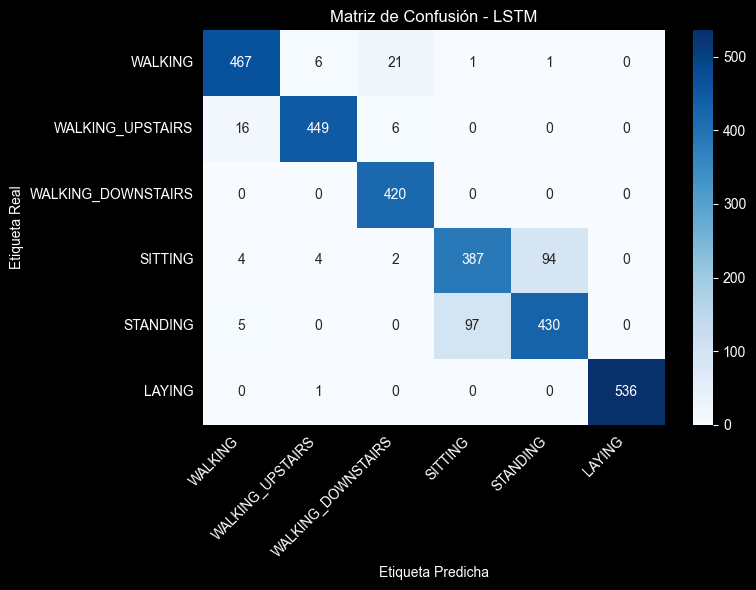

In [7]:
cm = confusion_matrix(y_test_int, y_pred_int)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión - LSTM')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/cm_lstm.png', dpi=100, bbox_inches='tight')
plt.show()

In [8]:
metricas_lstm = {
    'modelo': 'LSTM',
    'accuracy': accuracy_score(y_test_int, y_pred_int),
    'precision': precision_score(y_test_int, y_pred_int, average='weighted'),
    'recall': recall_score(y_test_int, y_pred_int, average='weighted'),
    'f1': f1_score(y_test_int, y_pred_int, average='weighted'),
    'tiempo_entrenamiento': tiempo_entrenamiento
}

for k, v in metricas_lstm.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

with open('../models/metricas_lstm.json', 'w') as f:
    json.dump(metricas_lstm, f)

modelo_lstm.save('../models/modelo_lstm.keras')
print('\nGuardado.')

  modelo: LSTM
  accuracy: 0.9125
  precision: 0.9121
  recall: 0.9125
  f1: 0.9121
  tiempo_entrenamiento: 479.7176

Guardado.


## 8. Comparación LSTM vs RNN

In [9]:
# Cargamos métricas de la RNN para comparar
with open('../models/metricas_rnn.json', 'r') as f:
    metricas_rnn = json.load(f)

print('Comparación RNN vs LSTM:')
print(f'{"Métrica":<15} {"RNN":<12} {"LSTM":<12}')
print('-' * 40)
for metrica in ['accuracy', 'precision', 'recall', 'f1']:
    val_rnn = metricas_rnn[metrica]
    val_lstm = metricas_lstm[metrica]
    print(f'{metrica:<15} {val_rnn:<12.4f} {val_lstm:<12.4f}')

print(f'\nTiempo RNN: {metricas_rnn["tiempo_entrenamiento"]:.1f}s')
print(f'Tiempo LSTM: {metricas_lstm["tiempo_entrenamiento"]:.1f}s')

Comparación RNN vs LSTM:
Métrica         RNN          LSTM        
----------------------------------------
accuracy        0.8317       0.9125      
precision       0.8335       0.9121      
recall          0.8317       0.9125      
f1              0.8318       0.9121      

Tiempo RNN: 105.9s
Tiempo LSTM: 479.7s


## Conclusiones del Modelo LSTM

La LSTM mejora a la RNN simple gracias a sus compuertas, que permiten:

1. **Recordar información a largo plazo** mediante el estado de celda, que actúa como una "cinta transportadora" que conserva información relevante a lo largo de toda la secuencia.
2. **Evitar el gradiente desvaneciente**, porque los gradientes pueden fluir sin modificarse a través de la compuerta de olvido cuando esta está abierta.
3. **Seleccionar qué información es relevante** para el problema actual.

Para el reconocimiento de actividades, esto se traduce en que la LSTM puede considerar toda la ventana temporal de 2.56 segundos de manera efectiva, mientras que la RNN tendía a ignorar los primeros pasos de tiempo.